In [1]:
 # !pip install torch torchvision torchaudio transformers scikit-learn datasets evaluate

In [23]:
# Install libraries

import numpy as np
from datasets import load_dataset

from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoModel

import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import accuracy_score, f1_score


In [4]:
raw_dataset = load_dataset("glue", "sst2")
raw_dataset

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [5]:
train_ds = raw_dataset["train"]
train_ds[10]

{'sentence': 'goes to absurd lengths ', 'label': 0, 'idx': 10}

In [6]:
train_ds.features

{'sentence': Value(dtype='string', id=None),
 'label': ClassLabel(names=['negative', 'positive'], id=None),
 'idx': Value(dtype='int32', id=None)}

In [7]:
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
def tokenize_data(data):
  res = tokenizer(data["sentence"], truncation=True, padding=False, max_length=None)
  res['labels'] = data['label']
  return res

tokenized_datasets = raw_dataset.map(tokenize_data, batched=True, remove_columns=["sentence", "label"])

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [9]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['idx', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1821
    })
})

In [36]:
# Dynamic Padding for train, validation and test datasets
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True, return_tensors = "pt")

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle = True,
    batch_size = 32,
    collate_fn = data_collator,
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"],
    shuffle = True,
    batch_size = 32,
    collate_fn = data_collator,
)

test_dataloader = DataLoader(
    tokenized_datasets["test"],
    shuffle = True,
    batch_size = 32,
    collate_fn = data_collator,
)

In [12]:
train_ds[5675]

{'idx': 5675,
 'input_ids': [101, 2053, 4895, 11787, 6348, 2030, 5107, 2806, 102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': 0}

In [13]:
# Defining the BERT+LSTM model

class BERT_LSTM(nn.Module):
  def __init__(self, bert_model_name = checkpoint, hidden_dim=256, num_classes=2, dropout_rate=0.3):
    super(BERT_LSTM, self).__init__()
    self.bert = AutoModel.from_pretrained(bert_model_name)
    self.dropout1 = nn.Dropout(dropout_rate) # Add dropout after BERT for regularization

    #Bidirectional LSTM
    self.lstm = nn.LSTM(
        input_size = self.bert.config.hidden_size,
        hidden_size=hidden_dim,
        batch_first=True,
        bidirectional=True,
        dropout=dropout_rate if hidden_dim > 1 else 0)

    self.dropout2 = nn.Dropout(dropout_rate) # Additional dropout before classification

    self.classifier = nn.Linear(hidden_dim*2, num_classes)


  def forward(self, input_ids, attention_mask):
    # Passing inputs through BERT
    outputs = self.bert(input_ids = input_ids, attention_mask = attention_mask)
    sequence_output = outputs[0]

    # Apply dropout after BERT
    sequence_output = self.dropout1(sequence_output)

    # Pass BERT output through LSTM head
    lstm_out, _ = self.lstm(sequence_output)

    # Get output from last token and apply dropout
    final_hidden = self.dropout2(lstm_out[:, -1, :])

    # Get output from last token
    output = self.classifier(final_hidden)

    return output

In [15]:
torch.cuda.is_available()

True

In [29]:
# Setting up the training parameters

# Initializing the model, optimizer and loss function
model = BERT_LSTM()
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

# Moving the model to available GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print
model.to(device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


cuda


BERT_LSTM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_aff

In [24]:
from tqdm.notebook import tqdm
from torch.cuda.amp import autocast, GradScaler

# Training Loop
scaler = GradScaler()
def train(model, train_dataloader, optimizer, loss_fn, device):
  model.train()
  total_loss=0
  all_preds=[]
  all_labels=[]

  for batch in tqdm(train_dataloader):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    # Zero out the gradients
    optimizer.zero_grad()

    with autocast():

      # Perform forward pass and compute loss
      outputs = model(input_ids, attention_mask)
      logits = outputs

      preds = torch.argmax(logits, dim=1)
      # preds = (logits > 0.5).long()
      loss = loss_fn(logits.squeeze(), labels)

      # Perform Backpropogation
      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()
      # Track metrics
      total_loss += loss.item()

      # labels = torch.argmax(labels, dim=1)

      all_preds.extend(preds.cpu().detach().numpy())
      all_labels.extend(labels.cpu().detach().numpy())

  all_preds = np.array(all_preds, dtype=int)
  all_labels = np.array(all_labels, dtype=int)
  avg_loss = total_loss / len(train_dataloader)
  accuracy = accuracy_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds, average='weighted')

  return avg_loss, accuracy, f1


<ipython-input-24-afde49a19b3e>:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [25]:
# Validation Loop to track overfitting
def evaluate(model, val_dataloader, loss_fn, device):
  model.eval()
  total_loss = 0
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for batch in tqdm(val_dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with autocast():
          outputs = model(input_ids, attention_mask)
          logits = outputs
          preds = torch.argmax(logits, dim=1)
          # loss = loss_fn(logits, labels)

          # preds = (logits > 0.5).long()
          loss = loss_fn(logits.squeeze(), labels)

          total_loss += loss.item()

          # labels = torch.argmax(labels, dim=1)
          all_preds.extend(preds.cpu().detach().numpy())
          all_labels.extend(labels.cpu().detach().numpy())

    all_preds = np.array(all_preds, dtype=int)
    all_labels = np.array(all_labels, dtype=int)

    avg_loss = total_loss / len(val_dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1


In [30]:
# Setting up the training pipeline

def train_model(model, train_dataloader, val_dataloader, device, num_epochs=3, lr=2e-5):
    # Setup the parameters
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()

    # Early stopping
    early_stopping = EarlyStopping(patience=3, verbose=True)

    # Learning rate scheduler - updates based on validation loss
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

    # Training and validation history
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }

    # Main training loop
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Training phase
        train_loss, train_acc, train_f1 = train(model, train_dataloader, optimizer, loss_fn, device)
        print(f"Train Loss: {train_loss:.3f} | Train Accuracy: {train_acc:.3f} | Train F1: {train_f1:.3f}")

        # Validation phase
        val_loss, val_acc, val_f1 = evaluate(model, val_dataloader, loss_fn, device)
        print(f"Validation Loss: {val_loss:.3f} | Validation Accuracy: {val_acc:.3f} | Validation F1: {val_f1:.3f}")

        # Update learning rate based on validation loss
        scheduler.step(val_loss)

        # Check early stopping
        early_stopping(val_loss, model)

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    # Load best model
    # model.load_state_dict(torch.load('best_model.pt'))

    return model, history


In [ ]:
torch.save(model.state_dict(), "bert_lstm_sentiment.pth")
from google.colab import files
files.download("bert_lstm_sentiment.pth")

Epoch 1/3


  0%|          | 0/2105 [00:00<?, ?it/s]

<ipython-input-24-afde49a19b3e>:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 0.207 | Train Accuracy: 0.919 | Train F1: 0.919


  0%|          | 0/28 [00:00<?, ?it/s]

...

<ipython-input-24-afde49a19b3e>:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 0.074 | Train Accuracy: 0.975 | Train F1: 0.975


  0%|          | 0/28 [00:00<?, ?it/s]

<ipython-input-25-2fecd6d2f3de>:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validation Loss: 0.274 | Validation Accuracy: 0.922 | Validation F1: 0.922
Early stopping counter: 1 out of 3

Training Complete!
Best validation accuracy: 0.9220
Best validation F1 score: 0.9220


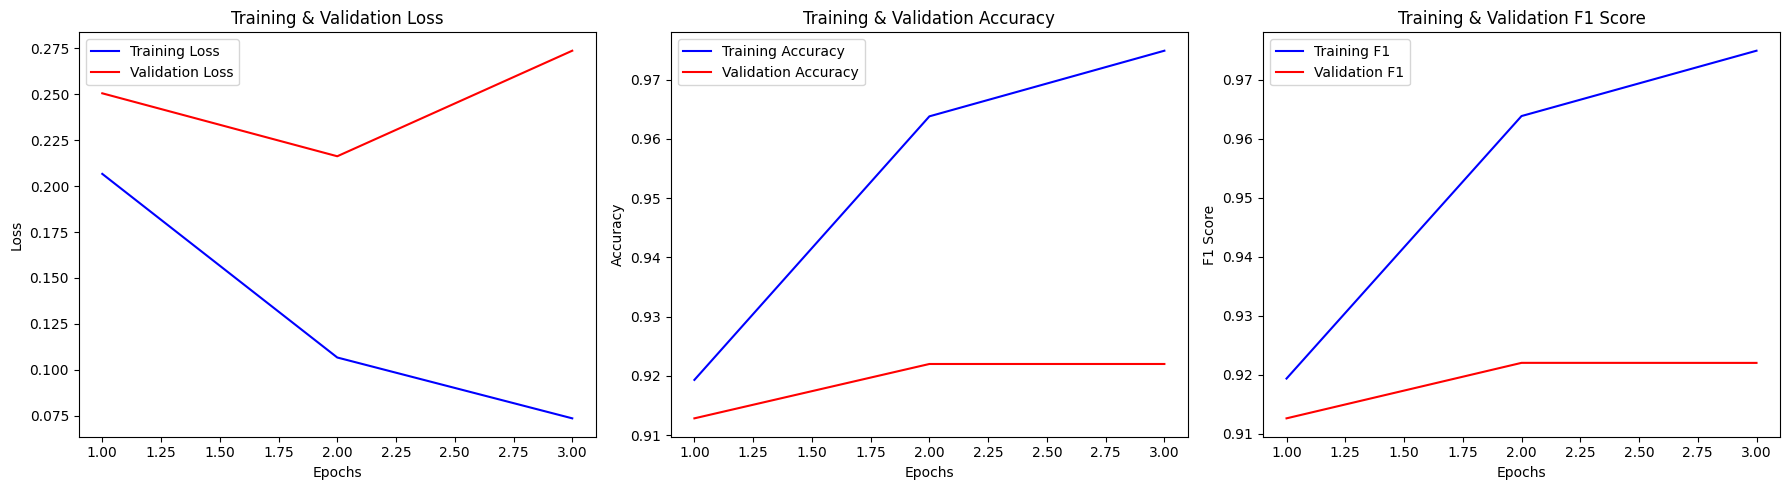

In [31]:
# Set training parameters
num_epochs = 3
learning_rate = 2e-5

# Call the train_model function
trained_model, history = train_model(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    device=device,
    num_epochs=num_epochs,
    lr=learning_rate
)

# Visualize the training history
import matplotlib.pyplot as plt

# Setup figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot Loss
epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Accuracy
ax2.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
ax2.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# Plot F1 Score
ax3.plot(epochs, history['train_f1'], 'b-', label='Training F1')
ax3.plot(epochs, history['val_f1'], 'r-', label='Validation F1')
ax3.set_title('Training & Validation F1 Score')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('F1 Score')
ax3.legend()

plt.tight_layout()
plt.show()

In [66]:
# Since the sst2 test data does not specify label, we can only make predictions, and cannot calculate the metrics
all_preds = []
test_ds = raw_dataset["test"]

model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())


In [76]:
for i in range (5):
  rndm_idx = np.random.randint(0, len(test_ds), 1)
  print(f"Test index number:{rndm_idx}")
  print(f"Sentence: {test_ds[rndm_idx]['sentence']}")
  print(f"Prediction:{all_preds[rndm_idx.item()]}")
  print('\n')


Test index number:[1164]
Sentence: ["a chaotic panorama that 's too busy flying a lot of metaphoric flags ."]
Prediction:0


Test index number:[1302]
Sentence: ["in scope , ambition and accomplishment , children of the century ... takes kurys ' career to a whole new level ."]
Prediction:1


Test index number:[105]
Sentence: ['the story ... is moldy and obvious .']
Prediction:1


Test index number:[1362]
Sentence: ['harsh , effective documentary on life in the israeli-occupied palestinian territories .']
Prediction:1


Test index number:[104]
Sentence: ['a splendid entertainment , young in spirit but accomplished in all aspects with the fullness of spirit and sense of ease that comes only with experience .']
Prediction:1


